In [37]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline


In [38]:
def f(x):
  return 3*x**2 -4*x + 5

In [39]:
f(3.0)

20.0

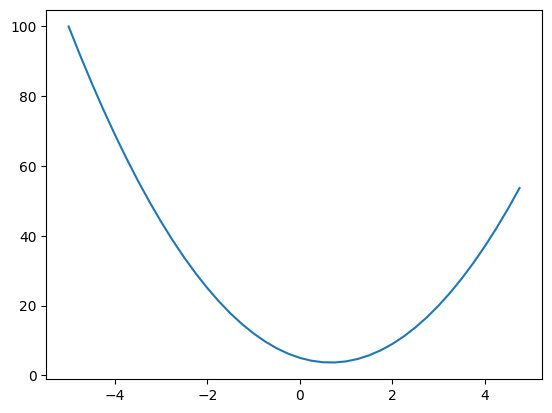

In [40]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [41]:
h = 0.000001
x = 2/3
(f(x+h) - f(x))/h

2.999378523327323e-06

In [42]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [43]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1',d1)
print('d2',d2)
print('slop', (d2 - d1)/h)


d1 4.0
d2 4.0001
slop 0.9999999999976694


In [44]:
import math

class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward
    return out

  def __sub__(self, other): # Added subtraction
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data - other.data, (self, other), '-')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad -= 1.0 * out.grad
    out._backward = _backward
    return out

  def __pow__(self, other): # Added power operation
    assert isinstance(other, (int, float)), "Only supporting int/float for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
      self.grad += (other * (self.data**(other-1))) * out.grad
    out._backward = _backward
    return out

  def __truediv__(self, other): # Added true division
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data / other.data, (self, other), '/')

    def _backward():
        self.grad += (1/other.data) * out.grad
        other.grad += (-self.data / (other.data**2)) * out.grad
    out._backward = _backward
    return out

  def __neg__(self): # Added unary negation
    return self * -1

  def __radd__(self, other):
    return self + other

  def __rmul__(self, other):
    return self * other

  def __rsub__(self, other): # Added reverse subtraction
    other = other if isinstance(other, Value) else Value(other)
    return other - self

  def tanh(self):
    x = self.data
    t = (math.exp(2*x)-1) / (math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += ( 1- t**2) * out.grad
    out._backward = _backward
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [45]:
# visualize
from graphviz import Digraph

def trace(root):
  #builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes,edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s |data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


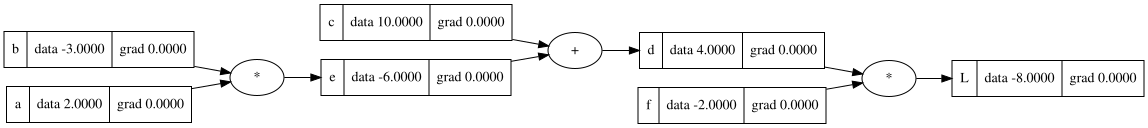

In [46]:
draw_dot(L)

In [47]:
# L = d *f
# dL/dd = ?

# (f(x+h) -f(x))/h
# ((d+h)*f - d*f)/h
# (d*f + h*f - d*f)/h
# (h*f)/h
# f

In [48]:
# dd/ dc?
# d = c+ e
# f(x+h) -f(x) / h # def of derivates
# ((c+h + e) -(c+e)) / h

In [49]:
#c.grad =  dL/ dc = (dL / dd) * (dd / dc) # chain rule
# by symetry e.grad = c.grad

In [50]:
L.grad = 1.0

In [51]:
def lol():

  h= 0.0001

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data

  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c ; d.label = 'd'
  d.data+= h
  f = Value(-2.0 , label='f')
  L = d * f; L.label = 'L'
  L2 = L.data

  print((L2 - L1)/h)
lol()

-1.9999999999953388


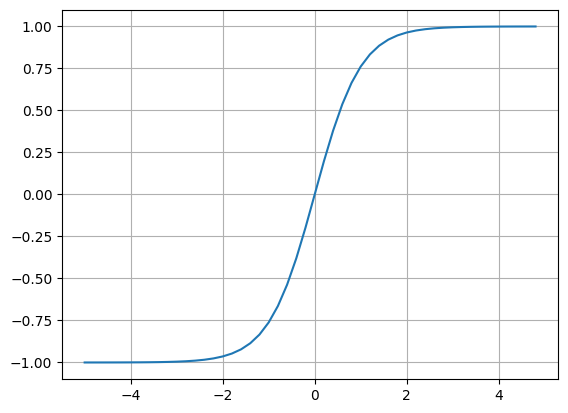

In [52]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [53]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
#bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 +x2*w2 +b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label= 'o';



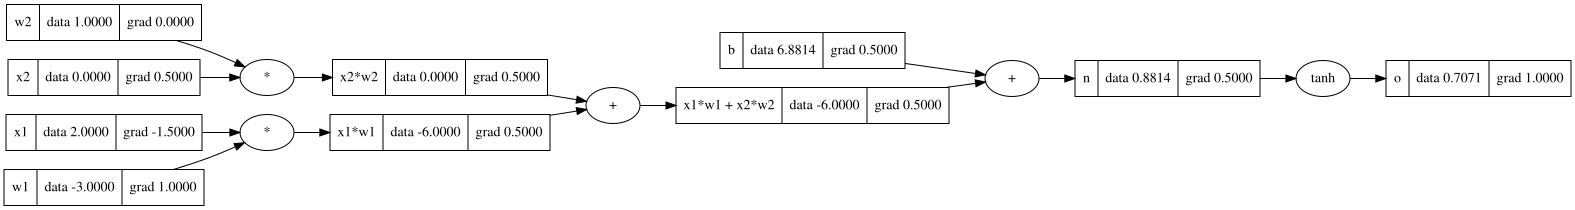

In [54]:
o.backward()
draw_dot(o)

In [55]:
# # back proprogate manually
# o.grad = 1.0 # base case nudge of o on o
# # o =tanh(n)
# # do/dn = 1- tanh(n) **2
# # do/dn = 1- o**2
# n.grad =  1 - o.data **2
# # x1w1x2w2.grad? b.grad? '+' is distributor of graidient local derivate of '+' is 1 so 1* 0.5 = 0.5
# b.grad = 0.5
# x1w1x2w2.grad = 0.5
# # x1w1.grad ?? same 1* 0.5 grad of b
# x1w1.grad = 0.5
# x2w2.grad = 0.5
# # now for last node we have '*' local derviate is othernode.data* currentnode.grad
# # so
# x2.grad = w2.data * x2w2.grad
# x1.grad = w1.data * x1w1.grad
# w2.grad = x2.data * x2w2.grad
# w1.grad = x1.data * x1w1.grad

In [56]:
# #topological sort
# topo = []
# visited = set()
# def build_topo(v):
#   if v not in visited:
#     visited.add(v)
#     for child in v._prev:
#       build_topo(child)
#     topo.append(v)
# build_topo(o)
# topo

In [57]:
# # base case
# o.grad = 1.0
# # doing back prop usng func
# o._backward()
# n._backward()
# b._backward()
# x1w1x2w2._backward()
# x1w1._backward()
# x2w2._backward()
# x2._backward()
# x1._backward()
# w2._backward()
# w1._backward()

In [58]:
import torch



In [59]:
x1 = torch.Tensor( [2.0]).double()                   ; x1.requires_grad = True
x2 = torch.Tensor( [0.0]).double()                   ; x2.requires_grad = True
w1 = torch.Tensor( [-3.0]).double()                  ; w1.requires_grad = True
w2 = torch.Tensor( [1.0]).double()                   ; w2.requires_grad = True
b = torch.Tensor( [6.8813735870195432]).double()     ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [60]:
class Neuron:

  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

Value(data=-0.3201631679958046)

In [ ]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)

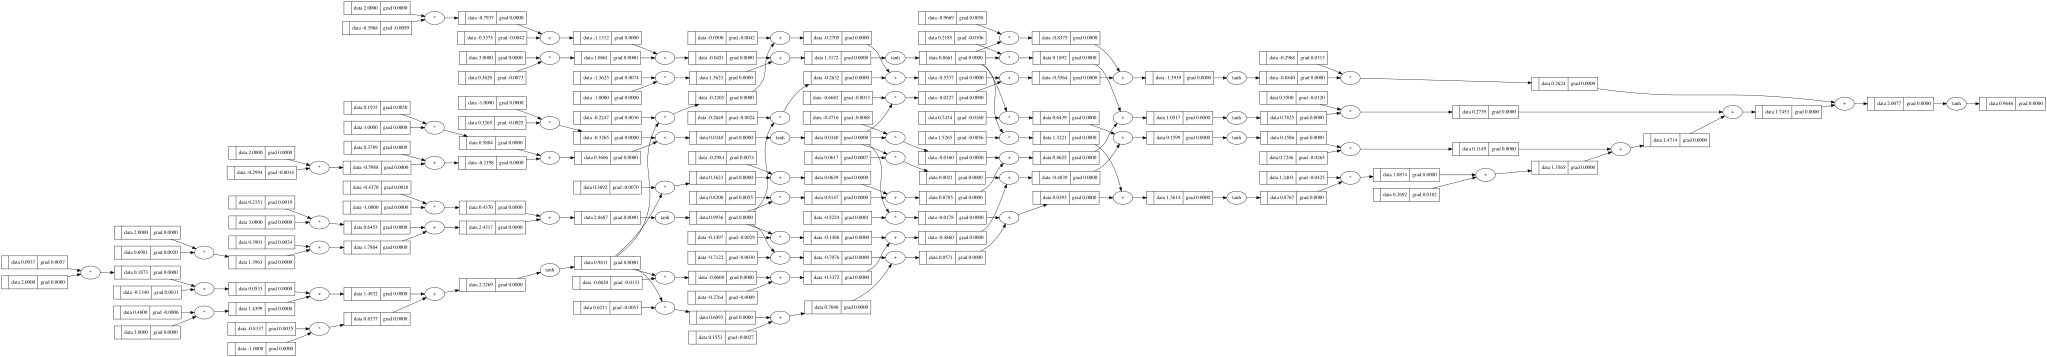

In [65]:
draw_dot(n(x))

In [62]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [63]:
for k in range(20):

  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad

  print(k, loss.data)

0 5.093807792234934
1 2.6369348438849127
2 0.04466048632969514
3 0.0383412094939339
4 0.03360816096931229
5 0.029921241988580885
6 0.02696345879669031
7 0.02453555287996619
8 0.022505540619507554
9 0.020782309295580205
10 0.0193008165935537
11 0.0180133242541003
12 0.01688396568297675
13 0.015885249973234643
14 0.014995738782703875
15 0.014198459427801093
16 0.013479794574387777
17 0.012828688862401853
18 0.012236071333126094
19 0.011694427913600884


In [64]:
ypred

[Value(data=0.963859418962461),
 Value(data=-0.9307505100535063),
 Value(data=-0.9414684455513345),
 Value(data=0.9534505468147764)]